In [ ]:
#Dillan Andrews, Nick Garcia
#https://www.kaggle.com/datasets/rohullahakbari12/weather-prediction

In [ ]:
#Import Libraries
import numpy as np                          # Common alias: np
import pandas as pd                         # Common alias: pd
import matplotlib.pyplot as plt             # Common alias: plt
import seaborn as sns                       # Common alias: sns
import random as rd

# From scikit-learn, we import specific tools we need:
from sklearn.model_selection import train_test_split   # Splits data into train/test
from sklearn.preprocessing import StandardScaler       # Scales features to same range
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier     # The KNN algorithm itself
from sklearn.metrics import (
    accuracy_score,           # What percentage did we get right?
    classification_report,    # Detailed per-class performance
    confusion_matrix          # Table showing correct vs incorrect predictions
)

In [ ]:
#Import Dataset
df = pd.read_csv('Weather_Data.csv')

#Keep only the first 500 data values
#dftrim = df[:500]

#Review the Data
print("Dataset Overview")
print("-" * 40)
print(f"Total number of cities: {df.shape[0]}")       # .shape[0] = row count
print(f"Number of features:    {df.shape[1] - 1}")      # -1 because 'Class' is a label, not a feature
print()

#Drop unneeded features
dftrim = df.drop(columns = ['Date','WindGustDir','WindDir9am','WindDir3pm','RainToday'])
#dftrim.head(10)

#Replace RainTomorrow yes/no with 1 and 0
#le = LabelEncoder()
#dftrim['RainTomorrow'] = le.fit_transform(dftrim['RainTomorrow'])
dftrim.head(10)

Dataset Overview
----------------------------------------
Total number of cities: 3271
Number of features:    21



,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
0,19.5,22.4,15.6,6.2,0.0,41,17,20,92,84,1017.6,1017.4,8,8,20.7,20.9,Yes
1,19.5,25.6,6.0,3.4,2.7,41,9,13,83,73,1017.9,1016.4,7,7,22.4,24.8,Yes
2,21.6,24.5,6.6,2.4,0.1,41,17,2,88,86,1016.7,1015.6,7,8,23.5,23.0,Yes
3,20.2,22.8,18.8,2.2,0.0,41,22,20,83,90,1014.2,1011.8,8,8,21.4,20.9,Yes
4,19.7,25.7,77.4,4.8,0.0,41,11,6,88,74,1008.3,1004.8,8,8,22.5,25.5,Yes
5,20.2,27.2,1.6,2.6,8.6,41,9,22,69,62,1002.7,998.6,6,6,23.8,26.0,Yes
6,18.6,26.3,6.2,5.2,5.2,41,15,15,75,80,999.0,1000.3,4,7,21.7,22.3,Yes
7,17.2,22.3,27.6,5.8,2.1,41,7,15,77,61,1008.3,1007.4,7,8,18.9,21.1,Yes
8,16.4,20.8,12.6,4.8,3.0,41,19,9,92,91,1006.4,1007.6,7,7,17.1,16.5,Yes
9,14.6,24.2,8.8,4.4,10.1,41,11,20,80,53,1014.0,1013.4,4,2,17.2,23.3,No


In [ ]:
# See the average difference between the two features
print("Average values per city variety:")
print(dftrim.groupby('RainTomorrow').mean().round(1))
print()
#This shows that the best indicators for a dissatisfied customer are the flight entertainment, and the distance of the flight

Average values per city variety:
              MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
RainTomorrow                                                      
0                14.7     23.4       1.6          5.3       8.4   
1                15.5     21.9       8.3          4.8       3.8   

              WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  \
RainTomorrow                                                           
0                      40.5          14.8          19.4         65.2   
1                      44.1          15.9          19.1         76.8   

              Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  \
RainTomorrow                                                              
0                    50.1       1018.5       1016.0       3.8       3.6   
1                    67.8       1017.9       1016.1       5.8       5.9   

              Temp9am  Temp3pm  
RainTomorrow                    
0                17.8     22.0  
1        

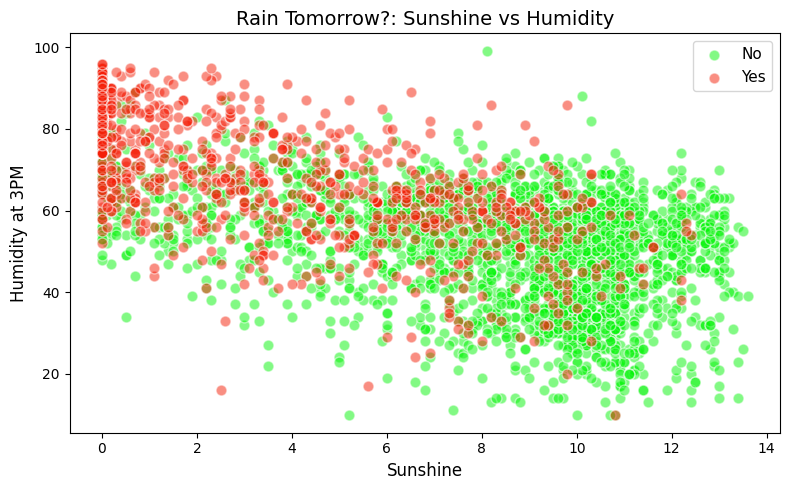

In [ ]:
#Create a Scatter Plot
plt.figure(figsize=(8, 5))  # Set the figure size (width=8, height=5 inches)

# Define colors for each seed variety
colors = {'No':'#07f50b', 'Yes':'#f51e07'}

# Loop through each variety and plot its points
for yesno, color in colors.items():
    # Filter the dataframe to only include this variety
    subset = dftrim[dftrim['RainTomorrow'] == yesno]

    # Plot a scatter plot
    plt.scatter(
        subset['Sunshine'],    # x-axis values
        subset['Humidity3pm'],         # y-axis values
        c=color,                # dot color
        label=yesno,        # legend label
        alpha=.5,              # transparency (0=invisible, 1=solid)
        edgecolors='w',         # white border around each dot
        s=60                    # dot size
    )

# Add labels and title (always label your axes!)
plt.xlabel('Sunshine', fontsize=12)
plt.ylabel('Humidity at 3PM', fontsize=12)
plt.title('Rain Tomorrow?: Sunshine vs Humidity', fontsize=14)
plt.legend(fontsize=11)          # Show the legend (color = which variety)
plt.tight_layout()               # Prevents labels from being cut off
plt.savefig('raintomorrow.png', dpi=150)  # Save as image file
plt.show()                       # Display the plot


In [ ]:
# --- Separate features from labels ---
# X = the input data (all columns EXCEPT 'RainTomorrow')
# y = the labels we want to predict (just the 'RainTomorrow' column)
X = dftrim.drop('RainTomorrow', axis=1)   # drop removes the 'RainTomorrow' column; axis=1 means "column"
y = dftrim['RainTomorrow']                # just grab the 'RainTomorrow' column

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape:   {y.shape}")
print()

Features (X) shape: (3271, 16)
Labels (y) shape:   (3271,)



In [ ]:
#Create a train test split: 20% of the data will be put aside for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # Reproducibility
    stratify=y           # Keep proportions balanced
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print()

Training samples: 2616
Testing samples:  655



In [ ]:
#Scale the two variables to ensure one does not overpower the other
scaler = StandardScaler()

# Learn mean & std from training data, then scale it
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data using the SAME mean & std (no new fitting!)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled using StandardScaler.")
print("   -> Training data: fit_transform (learn + scale)")
print("   -> Testing data:  transform only (scale using same parameters)")
print()

Features have been scaled using StandardScaler.
   -> Training data: fit_transform (learn + scale)
   -> Testing data:  transform only (scale using same parameters)



In [ ]:
#Train the KNN model

# Create a KNN classifier with K=5
# This just sets up the model — no learning happens yet
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model!
# .fit() stores all the training data internally.
# (KNN is a "lazy learner" — it doesn't build a complex model,
#  it just memorizes the training data and looks things up later)
knn.fit(X_train_scaled, y_train)

print("Model trained with K=5 neighbors.")
print()

# Make predictions on the test set
# For each test sample, KNN:
#   1. Calculates distance to ALL training samples
#   2. Finds the 5 closest ones
#   3. Takes a majority vote among those 5
y_pred = knn.predict(X_test_scaled)

print("Predictions made on the test set.")
print()

Model trained with K=5 neighbors.

Predictions made on the test set.



In [ ]:
# --- Overall accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
#   .2% formats as percentage with 2 decimal places
#   Example: 0.94 becomes "94.00%"
print()

# --- Detailed classification report ---
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))
#   precision = of all seeds we CALLED Cercevelik, how many really were?
#   recall    = of all ACTUAL Cercevelik seeds, how many did we catch?
#   f1-score  = the harmonic mean of precision and recall
#   support   = how many actual samples of each class were in the test set

Overall Accuracy: 80.46%

Detailed Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.93      0.88       485
         Yes       0.68      0.46      0.55       170

    accuracy                           0.80       655
   macro avg       0.76      0.69      0.71       655
weighted avg       0.79      0.80      0.79       655



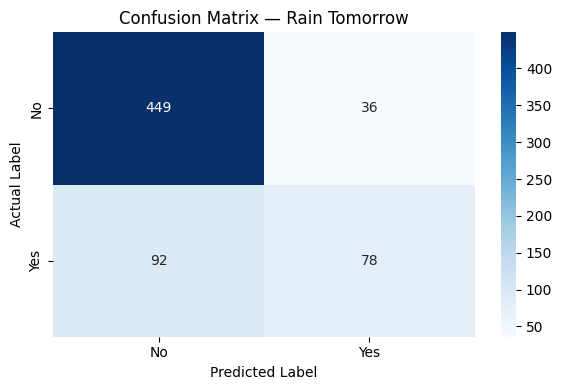

   -> Confusion matrix saved as 'Rainconfusion.png'



In [ ]:
# --- Confusion Matrix Heatmap ---
# This visual makes it easy to see where the model gets confused
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,                                        # The confusion matrix data
    annot=True,                                # Show numbers inside cells
    fmt='d',                                   # Format as integers (not decimals)
    cmap='Blues',                               # Blue color scheme
    xticklabels=['No', 'Yes'],       # Labels for predicted (x-axis)
    yticklabels=['No', 'Yes']        # Labels for actual (y-axis)
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Rain Tomorrow')
plt.tight_layout()
plt.savefig('Rainconfusion.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'Rainconfusion.png'")
print()

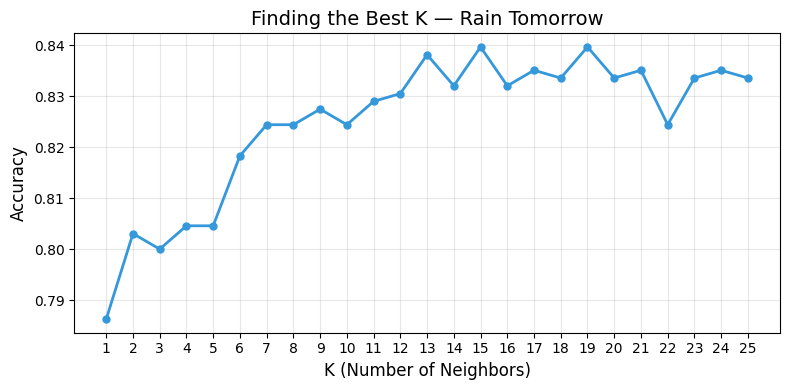

   -> Best K = 15
   -> Best Accuracy = 83.97%
   -> Chart saved as 'rain_best_k.png'



In [ ]:
# Test K values from 1 to 25
k_values = range(1, 26)
accuracies = []  # We'll store each K's accuracy here

for k in k_values:
    # Create a new model with this K
    model = KNeighborsClassifier(n_neighbors=k)

    # Train it on the same training data
    model.fit(X_train_scaled, y_train)

    # Predict on the test data
    pred = model.predict(X_test_scaled)

    # Calculate accuracy and save it
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(
    k_values,           # x-axis: K values
    accuracies,         # y-axis: accuracy for each K
    marker='o',         # Circle marker at each point
    color='#3498db',    # Blue color
    linewidth=2,        # Line thickness
    markersize=5        # Marker size
)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Best K — Rain Tomorrow', fontsize=14)
plt.xticks(k_values)      # Show every K value on x-axis
plt.grid(alpha=0.3)        # Faint grid lines for readability
plt.tight_layout()
plt.savefig('rain_best_k.png', dpi=150)
plt.show()

# Find the K with the highest accuracy
# np.argmax returns the INDEX of the maximum value in a list
best_k = list(k_values)[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"   -> Best K = {best_k}")
print(f"   -> Best Accuracy = {best_accuracy:.2%}")
print(f"   -> Chart saved as 'rain_best_k.png'")
print()

In [ ]:
#Prediction with new Weather data
# Retrain with the best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

# Imagine we measured a new pumpkin seed and got these values:
new_weather = pd.DataFrame({
    'MinTemp':      [rd.uniform(0,25)],    # Somewhere between the two varieties
    'MaxTemp':      [rd.uniform(0,40)],
    'Rainfall':     [rd.uniform(0,100)],
    'Evaporation':  [rd.uniform(0,10)],
    'Sunshine':     [rd.uniform(0,15)],
    'WindGustSpeed':[rd.uniform(0,41)],
    'WindSpeed9am': [rd.uniform(0,30)],
    'WindSpeed3pm': [rd.uniform(0,30)],
    'Humidity9am':  [rd.uniform(0,100)],
    'Humidity3pm':  [rd.uniform(0,100)],
    'Pressure9am':  [rd.uniform(0,1100)],
    'Pressure3pm':  [rd.uniform(0,1100)],
    'Cloud9am':     [rd.uniform(0,10)],
    'Cloud3pm':     [rd.uniform(0,10)],
    'Temp9am':      [rd.uniform(0,40)],
    'Temp3pm':      [rd.uniform(0,40)],
})

print("New weather measurements:")
print(new_weather.to_string(index=False))
print()

# Scale the new seed using the SAME scaler from training
# (Never create a new scaler for new data!)
new_weather_scaled = scaler.transform(new_weather)

# Make a prediction
prediction = final_model.predict(new_weather_scaled)
print(f"Predicted variety: {prediction[0]}")

# Get prediction probabilities
# This tells us what fraction of the K neighbors belong to each class
probabilities = final_model.predict_proba(new_weather_scaled)

print("Confidence scores:")
for class_name, prob in zip(final_model.classes_, probabilities[0]):
    # Create a simple bar visualization
    bar = '█' * int(prob * 30)  # Scale to 30 characters wide
    print(f"   {class_name:15s} {prob:6.1%}  {bar}")


New weather measurements:
 MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm   Temp9am  Temp3pm
0.795146 37.533194  5.641895     0.410669  8.590486      40.147949      3.584132      1.653374    92.309937    27.225224   628.544588  1018.794668  1.579528  0.120267 22.399573 11.82289

Predicted variety: No
Confidence scores:
   No               73.3%  ██████████████████████
   Yes              26.7%  ████████


The dataset used for this model involved over 4000 weather reports from Australia, taken every day starting in 2008. These weather reports included temperature, wind speeds, rainfall, and atmospheric pressure, all of which can be used to predict whether it would rain the next day. After comparing the average values on days when it rained to days when it didn't rain, we decided to use the hours of sunshine per day and the humidity at 3pm to predict whether it would rain the next day. Using the K Nearest Neighbors model, we were able to develop an algorithm that can predict tomorrow's rainfall with an accuracy of up to 83.97%. By entering the data collected from a regular weather report, we can use this model to accurately predict if it will rain the next day.   